In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [117]:
df = pd.read_csv('data/heart_failure_readmission_dataset.csv')
df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non-null   str    
 14  distance_to_hospital_km  3000 non-n

In [119]:
#identifying missing values
print(df[['bmi', 'sodium', 'creatinine']].isnull().sum())
# setting median for null values
df[['bmi', 'sodium', 'creatinine']] = df[['bmi', 'sodium', 'creatinine']].fillna(df[['bmi', 'sodium', 'creatinine']].median())

bmi           90
sodium        90
creatinine    90
dtype: int64


In [120]:
print("Shape:", df.shape)
print("\nClass distribution:\n", df['readmitted_30d'].value_counts())

Shape: (3000, 16)

Class distribution:
 readmitted_30d
0    1766
1    1234
Name: count, dtype: int64


In [121]:
# Theme
BG    = '#0D1117'; CARD  = '#161B22'; CARD2 = '#1C2430'
GREEN = '#3FB950'; RED   = '#F85149'; ACCENT= '#58A6FF'
TEXT  = '#E6EDF3'; MUTED = '#8B949E'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': '#30363D', 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': TEXT,
    'grid.color': '#21262D', 'grid.linewidth': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False,
})

PALETTE   = {0: GREEN, 1: RED}
label_map = {0: 'Not Readmitted', 1: 'Readmitted'}

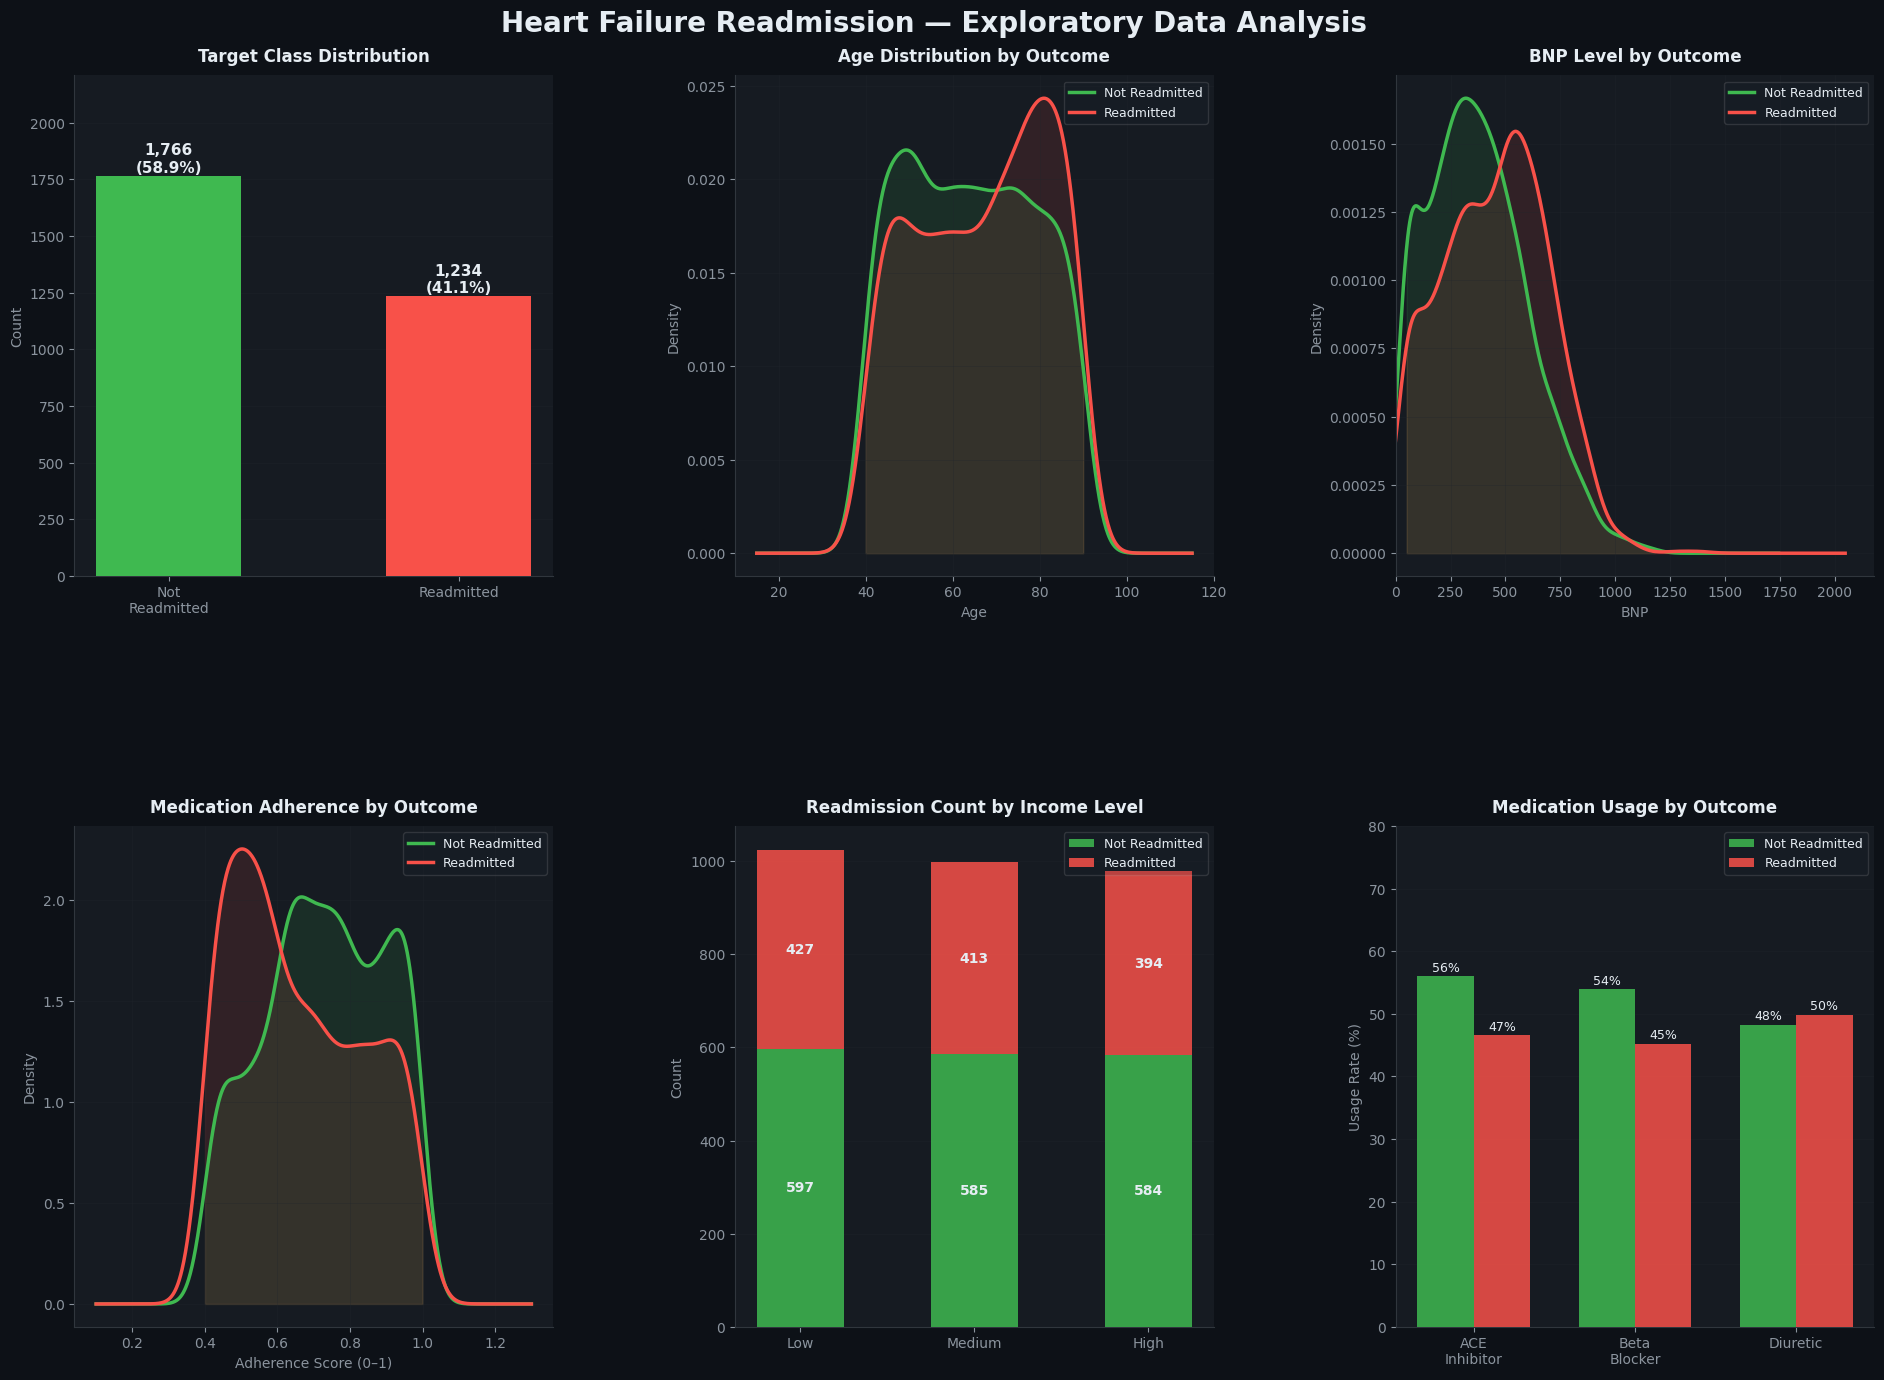

In [122]:
fig = plt.figure(figsize=(20, 22), facecolor=BG)
fig.suptitle('Heart Failure Readmission — Exploratory Data Analysis',
             fontsize=20, fontweight='bold', color=TEXT, y=0.99)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38,
                       top=0.96, bottom=0.05, left=0.07, right=0.97)

# Target Class Distribution
ax = fig.add_subplot(gs[0, 0])
counts = df['readmitted_30d'].value_counts().sort_index()
bars = ax.bar(['Not\nReadmitted', 'Readmitted'], counts.values,
              color=[GREEN, RED], width=0.5, edgecolor='none', zorder=3)
for bar, v in zip(bars, counts.values):
    pct = v / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=11,
            color=TEXT, fontweight='bold')
ax.set_title('Target Class Distribution', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.25)
ax.grid(axis='y', alpha=0.4)

# Age KDE by Outcome
ax = fig.add_subplot(gs[0, 1])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]['age']
    sub.plot.kde(ax=ax, color=color, linewidth=2.5, label=label_map[label])
    xvals = np.linspace(sub.min(), sub.max(), 200)
    yvals = np.interp(xvals, ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata())
    ax.fill_between(xvals, yvals, 0, color=color, alpha=0.12)
ax.set_title('Age Distribution by Outcome', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.15, facecolor=CARD2)
ax.grid(alpha=0.4)

# BNP KDE by Outcome
ax = fig.add_subplot(gs[0, 2])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]['bnp']
    sub.plot.kde(ax=ax, color=color, linewidth=2.5, label=label_map[label])
    xvals = np.linspace(sub.min(), sub.max(), 300)
    yvals = np.interp(xvals, ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata())
    ax.fill_between(xvals, yvals, 0, color=color, alpha=0.12)
ax.set_xlim(left=0)
ax.set_title('BNP Level by Outcome', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('BNP'); ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.15, facecolor=CARD2)
ax.grid(alpha=0.4)

# Adherence Score KDE
ax = fig.add_subplot(gs[1, 0])
for label, color in PALETTE.items():
    sub = df[df['readmitted_30d'] == label]['adherence_score']
    sub.plot.kde(ax=ax, color=color, linewidth=2.5, label=label_map[label])
    xvals = np.linspace(sub.min(), sub.max(), 200)
    yvals = np.interp(xvals, ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata())
    ax.fill_between(xvals, yvals, 0, color=color, alpha=0.12)
ax.set_title('Medication Adherence by Outcome', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Adherence Score (0–1)'); ax.set_ylabel('Density')
ax.legend(fontsize=9, framealpha=0.15, facecolor=CARD2)
ax.grid(alpha=0.4)

# Income Level Stacked Bar
ax = fig.add_subplot(gs[1, 1])
order   = ['Low', 'Medium', 'High']
inc_grp = (df.groupby(['income_level', 'readmitted_30d'])
             .size().unstack(fill_value=0).reindex(order))
bottom  = np.zeros(3)
for cls, color, lbl in [(0, GREEN, 'Not Readmitted'), (1, RED, 'Readmitted')]:
    vals = inc_grp[cls].values
    ax.bar(order, vals, 0.5, bottom=bottom, color=color,
           alpha=0.85, edgecolor='none', label=lbl, zorder=3)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 20:
            ax.text(i, b + v/2, str(v), ha='center', va='center',
                    fontsize=10, color=TEXT, fontweight='bold')
    bottom += vals
ax.set_title('Readmission Count by Income Level', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Count')
ax.legend(fontsize=9, framealpha=0.15, facecolor=CARD2)
ax.grid(axis='y', alpha=0.4)

# Medication Usage Grouped Bar
ax = fig.add_subplot(gs[1, 2])
meds       = ['ace_inhibitor', 'beta_blocker', 'diuretic']
med_labels = ['ACE\nInhibitor', 'Beta\nBlocker', 'Diuretic']
x = np.arange(3); w = 0.35
for i, (label, color) in enumerate(PALETTE.items()):
    sub   = df[df['readmitted_30d'] == label]
    rates = [sub[m].mean() * 100 for m in meds]
    bars  = ax.bar(x + i*w - w/2, rates, w, color=color, alpha=0.85,
                   edgecolor='none', label=label_map[label], zorder=3)
    for bar, v in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{v:.0f}%', ha='center', fontsize=9, color=TEXT)
ax.set_xticks(x); ax.set_xticklabels(med_labels, fontsize=10)
ax.set_title('Medication Usage by Outcome', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Usage Rate (%)')
ax.set_ylim(0, 80)
ax.legend(fontsize=9, framealpha=0.15, facecolor=CARD2)
ax.grid(axis='y', alpha=0.4)

plt.savefig('eda.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

The data not is fully imbalanced: 58,9% not readmitted and 41,1% readmitted classes.

**Age Distribution.** The dataset contains patients data 35+ age. The two KDE curves nearly overlap between 60–80, meaning age alone won't separate the classes well. The real signal is at the tails — under 55 (lower risk) and over 85 (higher risk). 

**BNP Distribution**. Both groups peak around 200–400, but the readmitted curve has a heavier right tail — meaning extremely high BNP (>800) is a stronger risk signal than moderate elevation.

**Medication Adherence.** The readmitted group peaks sharply around 0.5–0.6, while non-readmitted patients cluster toward 0.8–1.0. This is probably your strongest single predictor — the separation is cleaner here than in age or BNP. 

**Income Level.** The proportions are nearly identical across Low/Medium/High (~41% readmitted each). Income level alone has almost no predictive value in this dataset.

**Medication Usage.** ACE inhibitors and beta blockers are used less in readmitted patients (47% vs 56%, 45% vs 54%) — consistent with the adherence finding. Diuretic usage is slightly higher in readmitted patients (50% vs 48%), which makes clinical sense — sicker patients are more likely to be on diuretics.

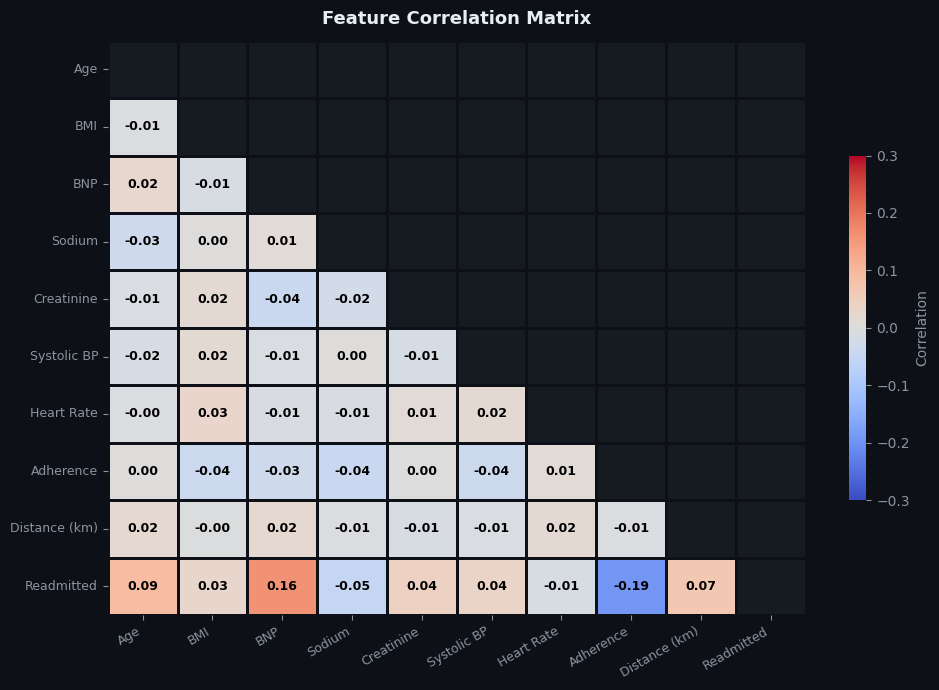

In [123]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)

num_cols = ['age','bmi','bnp','sodium','creatinine','systolic_bp',
            'heart_rate','adherence_score','distance_to_hospital_km','readmitted_30d']
readable = ['Age','BMI','BNP','Sodium','Creatinine','Systolic BP',
            'Heart Rate','Adherence','Distance (km)','Readmitted']
corr = df[num_cols].corr()
corr.index   = readable
corr.columns = readable
mask = np.triu(np.ones_like(corr, dtype=bool))

# ax.set_facecolor('white')
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=0.3, vmin=-0.3, center=0,
            annot=True, fmt='.2f', linewidths=1.0, linecolor='#0D1117',
            ax=ax, annot_kws={'size': 9, 'color': 'black', 'weight': 'bold'},
            cbar_kws={'shrink': 0.6, 'label': 'Correlation'})

ax.set_title('Feature Correlation Matrix', color=TEXT, fontsize=13, fontweight='bold', pad=12)
ax.tick_params(labelsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

No multicollinearity problem, no two features are highly correlated with each other - each parameter brings independent information.

### Feature Engineering

In [124]:
# Log-transform BNP (reduces right skew)
df['log_bnp'] = np.log1p(df['bnp'])

# Age groups separation
df['age_group'] = pd.cut(df['age'], bins=[0, 55, 75, 120], labels=['<55', '55-75', '>75'])

# how many medications the patient is on
df['medication_count'] = df[['ace_inhibitor', 'beta_blocker', 'diuretic']].sum(axis=1)

# categorical variables
df['gender_enc']    = LabelEncoder().fit_transform(df['gender'])
df['income_enc']    = df['income_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['age_group_enc'] = df['age_group'].map({'<55': 0, '55-75': 1, '>75': 2})


feature_cols = [
    # 'age', 
    'age_group_enc',
    'bmi', 'log_bnp',
    'sodium', 'creatinine',
    'systolic_bp', 'heart_rate',
    # 'ace_inhibitor', 'beta_blocker',
    # 'diuretic', 
    'medication_count',
    'adherence_score', 
    # 'access_score',
    # 'distance_to_hospital_km',
    'gender_enc'
    # , 'income_enc'
]

# Train/Test Split (50/50)
X = df[feature_cols]
y = df['readmitted_30d']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=99, stratify=y)

Testing  accuracy: 0.625


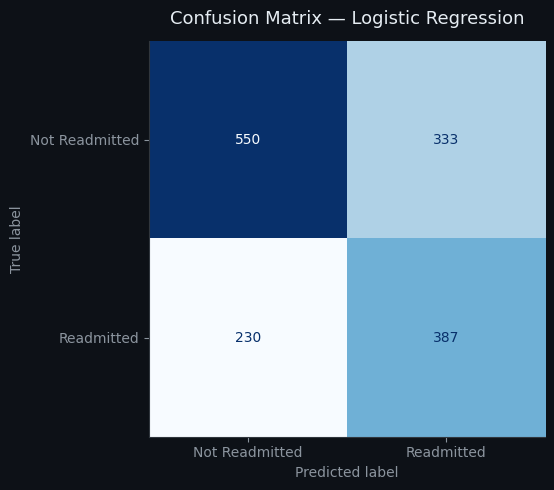

In [125]:
# Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

log_reg_classifier = LogisticRegression(class_weight='balanced')
log_reg_classifier.fit(X_train_sc, y_train)

y_pred = log_reg_classifier.predict(X_test_sc)
y_prob = log_reg_classifier.predict_proba(X_test_sc)[:, 1]
accuracy = np.mean(y_pred == y_test)
print(f"Testing  accuracy: {accuracy:.3f}")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

plt.title("Confusion Matrix — Logistic Regression", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

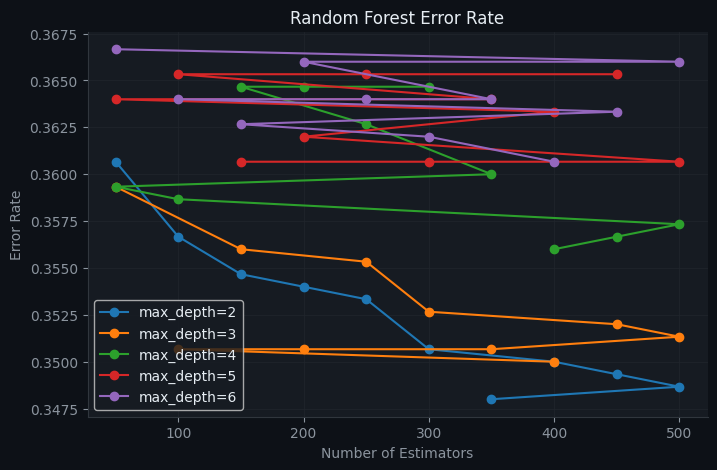

Best params -> N=350, d=2, error=0.3480, accuracy=0.6520


In [126]:
# Random Forest
subtrees_num=np.arange(50, 501, 50)
depths=np.arange(2, 7)
results = []
for n in subtrees_num:
    for d in depths:
        model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=99, class_weight='balanced')
        model.fit(X_train, y_train)
        predicted = model.predict(X_test)
        err_rate = np.mean(predicted != y_test)
        results.append((n, d, err_rate))
        
        
results_df = pd.DataFrame(results, columns=['n_estimators', 'max_depth', 'error_rate'])
plt.figure(figsize=(8,5))
for d in depths:
    subset = results_df[results_df['max_depth'] == d].sort_values(['error_rate', 'n_estimators', 'max_depth'], ascending=[True, True, True])
    plt.plot(subset['n_estimators'], subset['error_rate'], marker='o', label=f'max_depth={d}')
plt.xlabel('Number of Estimators')
plt.ylabel('Error Rate')
plt.title('Random Forest Error Rate')
plt.legend()
plt.grid()
plt.show()

best = results_df.sort_values(['error_rate','n_estimators','max_depth'], ascending=[True, False, True]).iloc[0]
best_N, best_d = int(best.n_estimators), int(best.max_depth)
print(f"Best params -> N={best_N}, d={best_d}, error={best.error_rate:.4f}, accuracy={1-best.error_rate:.4f}")

rf_classifier = RandomForestClassifier(n_estimators=best_N, max_depth=best_d, criterion='gini', random_state=99, class_weight='balanced')
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)


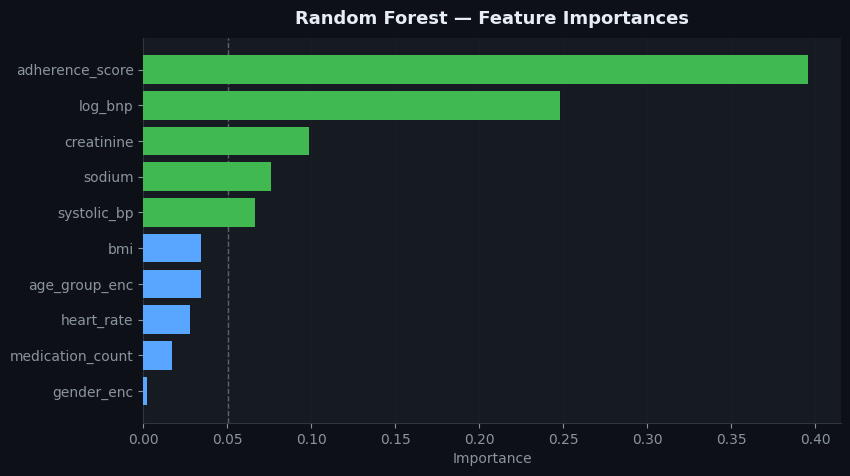

In [127]:
# Feature importances (RF)
fi = pd.Series(rf_classifier.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fi_labeled = pd.Series(rf_classifier.feature_importances_, index=feature_cols).sort_values()
colors_fi = [GREEN if v > fi_labeled.median() else ACCENT for v in fi_labeled]
ax.barh(fi_labeled.index, fi_labeled.values, color=colors_fi, edgecolor='none', zorder=3)
ax.set_title('Random Forest — Feature Importances', color=TEXT, fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.4)
ax.axvline(fi_labeled.median(), color=MUTED, linestyle='--', linewidth=1, alpha=0.6)
 

Feature Importance confirms EDA findings: 
- adherence score, bnp are by far the strongest
- creatinine, sodium, systolic_bp contribute meaningfully
- bmi, age, heart rate, medication count, gender don't have impact for prediction — could be dropped

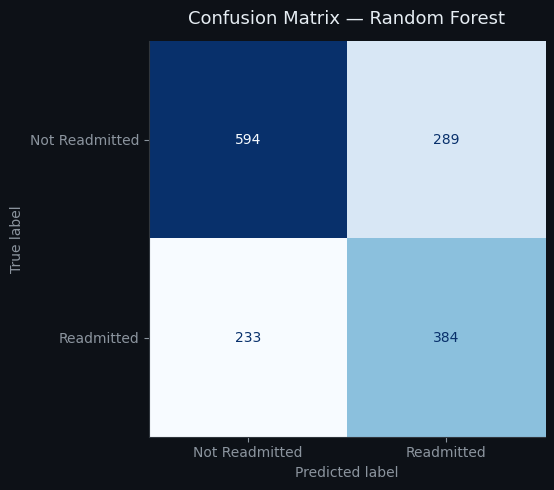

In [128]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

plt.title("Confusion Matrix — Random Forest", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

Testing accuracy: 0.645


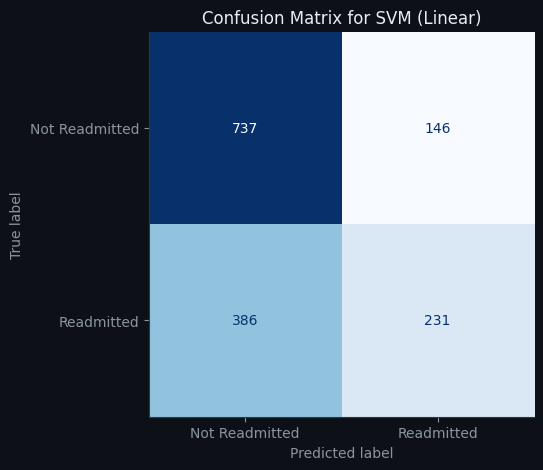

In [129]:
# SVM
from sklearn import svm

svm_classifier = svm.SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)
accuracy = np.mean(y_pred==y_test)
print(f"Testing accuracy: {accuracy:.3f}")


cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("Confusion Matrix for SVM (Linear)")
plt.show()

### Summary
All three models missed ~380 readmitted patients (FN) — predicting them as safe when they were not. After applying class_weight='balanced', FN dropped to ~230, meaning the models now catch more at-risk patients, which is the more important error to minimize in a clinical setting.

The trade-off: fixing FN came at the cost of more FP (healthy patients flagged as at-risk), and overall accuracy stayed flat at ~65%. This is expected — balanced weighting shifts the decision boundary, it doesn't add new information.

For Random Forest, more estimators were needed to stabilize predictions after reweighting, which is normal since balanced weighting increases tree variance.

The ~65% accuracy ceiling across all three models suggests the signal in this dataset is genuinely weak — no single feature correlates with readmission above 0.19. The models are not underperforming; the features simply do not separate the two classes cleanly enough on their own.